In [2]:
# fix relative imports
import os
cwd = os.path.normpath(os.getcwd())
cwd = cwd.split(os.sep)
find = cwd.index("fidelity-phase-tran")
newdir = f"{os.sep}".join(cwd[:find+1])
os.chdir(newdir)

# import known packages
import numpy as np

from scipy import signal

from matplotlib import pyplot as plt

# import adhoc packages
from qs_mps.applications.ANNNI.ground_state_multiprocessing import ground_state_ANNNI
from qs_mps.utils import get_precision, tensor_shapes
from qs_mps.mps_class import MPS

from qphaset.fidelity import uhlmann_fidelity, fidelity_laplacian
from qphaset.filters import SOBEL, SOBEL_X, bump_kernel, upsampling_base
from qphaset.models import get_rdm, params_2d_lattice

# Adaptive DMRG Sampling

We can think of finding the ground states of the ANNNI model through a grid search in the parameter space of the Hamiltonian. However, it could be that in some regions of the phase diagram the DMRG algorithm, and more specifically the Implicitly Restarted Arnoldi Method (IRAM) built in `scipy.sparse.linalg.eigsh`, does not reach convergence.  
Hence, we could adapt the ground state search strategy using another metric of convergence, the Uhlmann Fidelity, implemented with `qphaset.fidelity.uhlmann_fidelity` between two rdms slightly shifted in the parameter space
$$ f (\lambda,v) = \sqrt{F}(\rho(\lambda),\rho(\lambda+v)) $$  

Let us organize the steps of the adaptive sampling algorithm:
1. Choose two nearest points in the parameter space $(\lambda_i,\lambda_{i+1})$ that we know to be easy to compute 
2. Compute the $f(\lambda_i,\lambda_{i+1})$ and compare with a predefined threshold  
3. 
    if $f<\text{threshold}$:  
    - try the computation with the previous state as a guess and timeout given by the mean of previous computations  
    - try the computation with a random guess and timeout given by the mean of previous computations  
    - skip the point $\lambda_{i+2}$ in the grid and compute $\lambda_{i+3}$,$\lambda_{i+4}$  

    else:  
    - continue the grid search in the standard way


In [5]:
L = 60
chi = 128
path_tensor = "/Users/fradm98/Desktop/projects/2_ANNNI"

h_i = 0.0
h_f = 1.5
npoints = 32 
grid = np.linspace(h_i,h_f,npoints)
precision = get_precision(num=(h_f-h_i)/npoints)
args_mps = {
            "L": L,
            "d": 2,
            "chi": chi,
            "type_shape": "rectangular",
            "model": "ANNNI",
            "trunc_tol": False,
            "trunc_chi": True,
            "where": L//2,
            "bond": True,
            "path": path_tensor,
            "save": True,
            "precision": precision,
            "eps": 0,
        }

# ANNNI

In [7]:
# for h in grid:
#     for i in range(len(grid)-1):
#         lambs = [grid[i],grid[i+1]]
#         param = [[h,k] for k in lambs]
#         energy, entropy, schmidt_vals = ground_state_ANNNI(args_mps=args_mps, multpr=True, param=param)
param = [np.flip(grid,axis=0), grid]
energy, entropy, schmidt_vals = ground_state_ANNNI(args_mps=args_mps, multpr=False, param=param, init=True)

Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 119
total time: 57.954892449999534
##############################
energy of h:1.50, k:0.00 is:
 [-100.13156561503989, -100.13156561503992, -100.13156561503996, -100.13156561503993, -100.13156561503999, -100.1315656150401, -100.13156561504034, -100.13156561504016, -100.13156561504006, -100.13156561503996, -100.13156561504017, -100.13156561503976, -100.13156561504002, -100.13156561503973, -100.13156561503976, -100.1315656150397, -100.13156561503975, -100.1315656150399, -100.13156561503983, -100.1315656150397, -100.13156561503958, -100.13156561503976, -100.13156561503969, -100.13156561503946, -100.13156561503966, -100.13156561503962, -100.13156561503982, -100.13156561503973, -100.13156561503946, -100.13156561503986, -100.1315656150399, -100.1315656150396, -100.13156561503958, -100.1315656150395, -100.1315656150395, 

KeyboardInterrupt: 

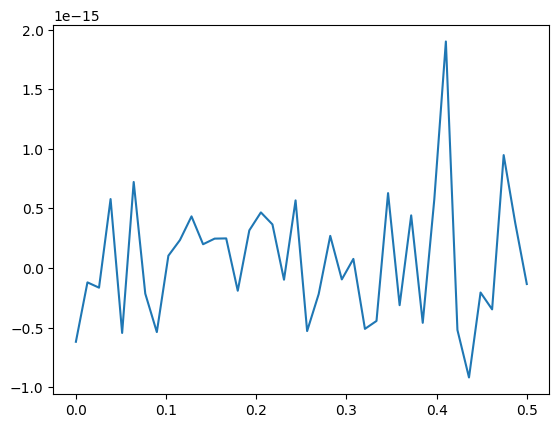

In [35]:
mag = []
op = np.array([[1,0],[0,-1]])
# op = np.array([[0,1],[1,0]])
for h in [grid[0]]:
    for k in grid:
        mps = MPS(L=L, d=2, model="ANNNI", chi=chi, h=h, k=k, J=1)
        mps.load_sites(path=path_tensor, precision=precision)
        mps.order_param_Ising(op=op)
        m = mps.mpo_first_moment().real/L
        mag.append(m)

mag = np.array(mag)
# mag = np.array_split(mag, len(grid))
# plt.matshow(mag, origin='lower')
# plt.colorbar()
plt.plot(grid, mag)

# ISING

In [4]:
init_state = np.zeros((1, 2, 1))
init_state[:, :, :] = (1/np.sqrt(2))**args_mps["L"]
init_tensor = [init_state for _ in range(L)]
J = 1
Z = np.array([[1,0],[0,-1]])
X = np.array([[0,1],[1,0]])

for h in grid:
    precision = args_mps["precision"]
    chain = MPS(
        L=args_mps["L"],
        d=args_mps["d"],
        model="Ising",
        chi=args_mps["chi"],
        h=h,
        J=J,
        eps=args_mps["eps"],
    )
    chain.sites = init_tensor
    chain.enlarge_chi(type_shape="rectangular", prnt=False)
    # chain._random_state(seed=7, chi=args_mps["chi"], type_shape=args_mps["type_shape"])
    chain.canonical_form(trunc_chi=True, trunc_tol=False)
    # total
    chain.local_param(op=X, site=args_mps["L"]//2)
    mag = np.real(chain.mpo_first_moment())
    print(mag)
    if mag < 0:
        chain.flipping_all()

    energy, entropy, schmidt_vals = chain.DMRG(
        trunc_tol=args_mps["trunc_tol"],
        trunc_chi=args_mps["trunc_chi"],
        where=args_mps["where"],
        bond=args_mps["bond"],
        long="X",
        trans="Z",
    )

    print(f"energy of h:{h:.{precision}f}, J:{J:.{precision}f} is:\n {energy}")
    print(f"Schmidt values in the middle of the chain:\n {schmidt_vals}")

    chain.save_sites(path=args_mps["path"], precision=args_mps["precision"])

0.9999999999999868
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 119
total time: 15.552219127000171
##############################
energy of h:0.00, J:1.00 is:
 [-58.999999999999204, -58.99999999999923, -58.99999999999927, -58.99999999999929, -58.999999999999325, -58.99999999999943, -58.99999999999938, -58.99999999999942, -58.99999999999967, -58.999999999999474, -58.999999999999524, -58.99999999999952, -58.99999999999954, -58.999999999999595, -58.9999999999996, -58.99999999999959, -58.999999999999616, -58.99999999999964, -58.999999999999645, -58.99999999999966, -58.99999999999968, -58.9999999999997, -58.99999999999974, -58.999999999999744, -58.99999999999978, -58.999999999999815, -58.999999999999844, -58.99999999999986, -58.99999999999988, -58.99999999999991, -58.99999999999993, -58.99999999999995, -58.99999999999998, -58.99999999999999, -59.00000000000002, 

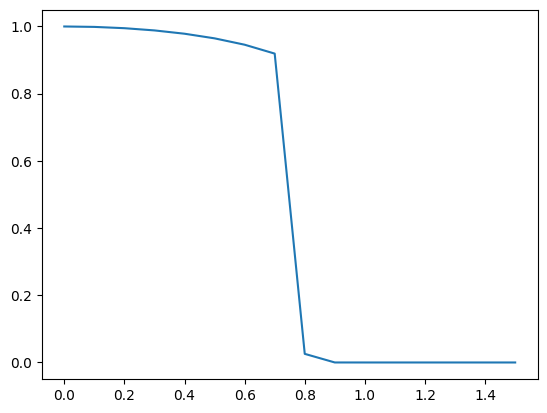

In [31]:
mag = []
op = np.array([[0,1],[1,0]])
# op = np.array([[1,0],[0,-1]])
for h in grid:
    mps = MPS(L=L, d=2, model="Ising", chi=chi, h=h, J=1)
    mps.load_sites(path=path_tensor, precision=precision)
    mps.local_param(op=op, site=L//2)
    m = mps.mpo_first_moment().real
    mag.append(m)

plt.plot(grid,mag)

In [27]:
# fs_mat = np.zeros((len(grid),len(grid)))
# fs = []
# # rdms = []
# for h in grid:
#     for i in range(len(grid)-1):
#         lambs = [grid[i],grid[i+1]]
#         param = [[h,k] for k in lambs]
#         rho_1 = MPS(L=L, d=2, model="ANNNI", chi=chi, h=param[0][0], k=param[0][1], J=1)
#         rho_2 = MPS(L=L, d=2, model="ANNNI", chi=chi, h=param[1][0], k=param[1][1], J=1)
#         rho_1.load_sites(path=path_tensor, precision=precision)
#         rho_2.load_sites(path=path_tensor, precision=precision)
#         rdm_1 = rho_1.reduced_density_matrix([L//2-1,L//2,L//2+1]).reshape((2**3,2**3))
#         rdm_2 = rho_2.reduced_density_matrix([L//2-1,L//2,L//2+1]).reshape((2**3,2**3))
#         f = uhlmann_fidelity(d1=rdm_1, d2=rdm_2, sqrt=True)
#         fs.append(f)
#         rdms.append(rdm_1)

# rdms = np.array(rdms)

fs_mat = np.zeros((len(grid),len(grid)))
fs = []
rdms = []
for h in grid:
    for k in grid:
        rho_1 = MPS(L=L, d=2, model="ANNNI", chi=chi, h=h, k=k, J=1)
        rho_1.load_sites(path=path_tensor, precision=precision)
        rdm_1 = rho_1.reduced_density_matrix([(L//2),(L//2)+1]).reshape((2**2,2**2))
        rdms.append(rdm_1)

rdms = np.array(rdms)
print(rdms.shape)

(1024, 4, 4)


In [28]:
rdms = rdms.reshape((32,32,4,4))


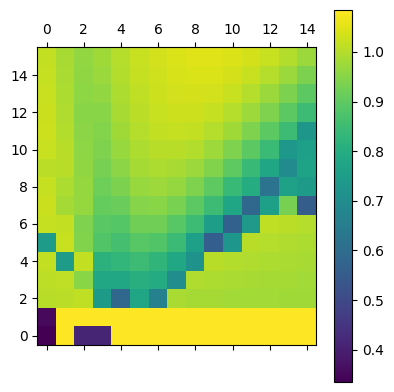

In [60]:
# a = [fs[i*32:32*(i+1)] for i in range(15)]

plt.matshow(np.asarray(fs).reshape((16,15)), origin='lower')
plt.colorbar()

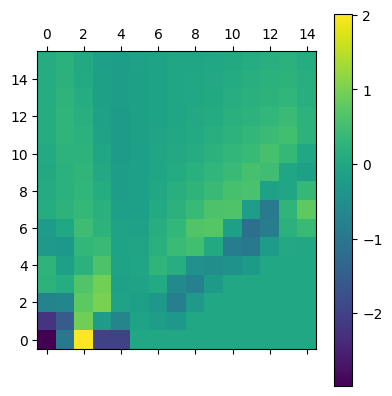

In [66]:
from scipy import signal
from qphaset.filters import SOBEL
f_conv = signal.convolve2d(np.asarray(fs).reshape((16,15)), SOBEL, boundary='symm', mode='same')
plt.matshow(np.real(f_conv), origin='lower')
plt.colorbar()

In [29]:
# Grad laplacian filter with upsampling
kernel = bump_kernel(6, scale=2)
kernel = signal.convolve2d(kernel, SOBEL, boundary='symm', mode='same')

g = fidelity_laplacian(rdms)
g = upsampling_base(g)
grad_g = signal.convolve2d(g, kernel, boundary='symm', mode='same')


# TODO Consider pixel centering.
params = [[h,k] for h in grid[2:] for k in grid[2:]]
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])
n1 = len(grad_g)
params1 = params_2d_lattice(params_extent[:2], params_extent[2:], n=n1)

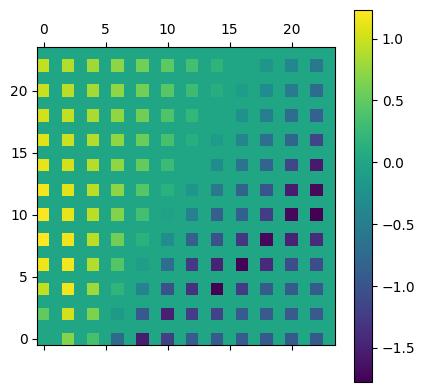

In [98]:
plt.matshow(g.real, origin='lower')
plt.colorbar()

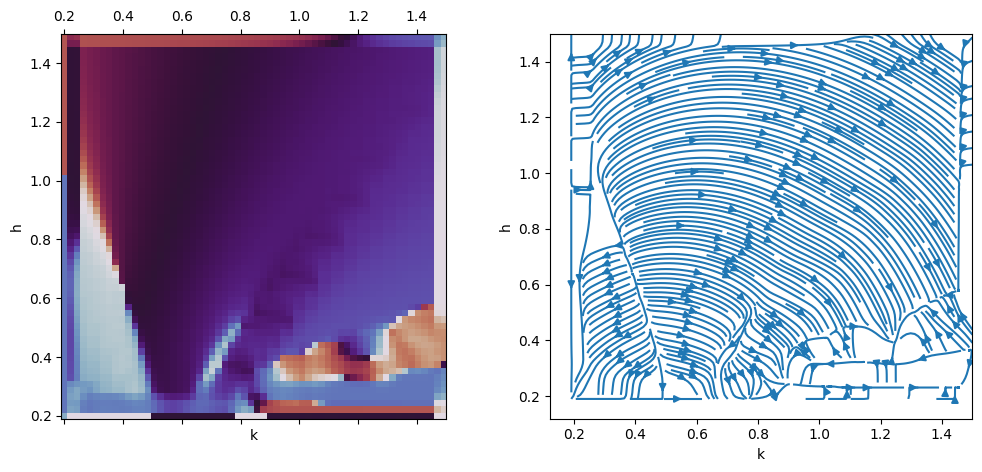

In [30]:
axis_name = ['k', 'h']

ig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].matshow(np.angle(grad_g), origin='lower', cmap='twilight', extent=params_extent, aspect='equal',
               vmin=-np.pi, vmax=np.pi)
axs[0].set_xlabel(axis_name[0])
axs[0].set_ylabel(axis_name[1])

X, Y = params1[:, 0].reshape((n1, n1)), params1[:, 1].reshape((n1, n1))
# if workflow_stable:
#    X, Y = X[1:-1, 1:-1], Y[1:-1, 1:-1]   # Used by stable algorithm.
#ngrad_g = np.abs(grad_g)[::2, ::2]
#axs[1].quiver(np.real(grad_g[::2, ::2])/ngrad_g, np.imag(grad_g[::2, ::2])/ngrad_g)
axs[1].streamplot(X, Y, np.real(grad_g), np.imag(grad_g), density=3)
axs[1].set_xlabel(axis_name[0])
axs[1].set_ylabel(axis_name[1]);

In [28]:
h = 0
L = 4
chi = 4
init_state = np.zeros((1, 2, 1))
init_state[:, :, :] = (1/np.sqrt(2))**L
init_tensor = [init_state for _ in range(L)]
for k in grid:
    mps = MPS(L=L, d=2, model="ANNNI", chi=chi, h=h, k=k, J=1)
    mps.sites = init_tensor.copy()
    print(init_tensor[1])
    print(mps.sites[2])
    mps.enlarge_chi()
    mps.canonical_form(trunc_chi=True, trunc_tol=False)
    mps.local_param(site=2, op=np.array([[0,1],[1,0]]))
    print(mps.mpo_first_moment().real)
    mps.DMRG(trunc_chi=True, trunc_tol=False, long="X", trans="Z")
    mps.local_param(site=2, op=np.array([[0,1],[1,0]]))
    print(mps.mpo_first_moment(site=2).real)


[[[0.25]
  [0.25]]]
[[[0.25]
  [0.25]]]
3.9999999999999982
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 6.000000000000004
instead of the convergence tolerance 1e-10
total time: 0.01892943699931493
##############################
-1.5715588346199845e-31
[[[0.25]
  [0.25]]]
[[[0.25]
  [0.25]]]
3.9999999999999982
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 7
total time: 0.01789553300022817
##############################
3.112751003237478e-31
[[[0.25]
  [0.25]]]
[[[0.25]
  [0.25]]]
3.9999999999999982
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 7
total time: 0.0179154240004209
##############################
-2.1285362945325033e-31
[[[0.25]
  [0.25]]]
[

# ANNNI exact

-9.0 -9.000000000000014
-9.053333333333333 -9.053333333333354
-9.106666666666667 -9.106666666666666
-9.16 -9.16
-9.213333333333333 -9.213333333333356
-9.266666666666667 -9.266666666666667
-9.319999999999999 -9.320000000000014
-9.373333333333333 -9.373333333333333
-9.426666666666668 -9.426666666666666
-9.48 -9.480000000000015
-9.533333333333333 -9.533333333333333
-9.586666666666668 -9.586666666666684
-9.639999999999999 -9.64
-9.693333333333333 -9.693333333333333
-9.746666666666666 -9.746666666666675
-9.800000000000002 -9.8


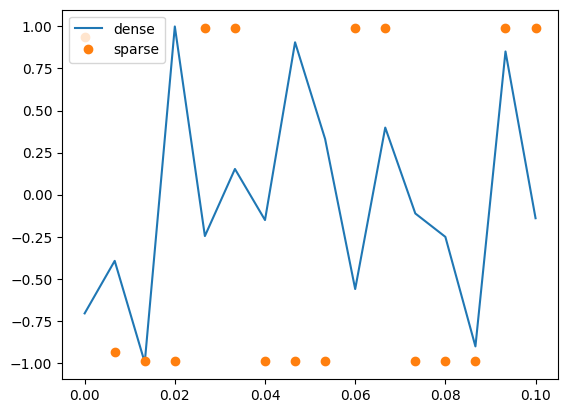

In [54]:
from qs_mps.sparse_hamiltonians_and_operators import sparse_pauli_x, sparse_pauli_z, identity
from ncon import ncon
import scipy as scipy
from scipy.sparse.linalg import eigsh

def ANNNI(L,k, eps=0):
    H_nnn = 0
    H_nn = 0
    H_n = 0
    for i in range(L-2):
        H_nnn += sparse_pauli_x(n=i,L=L) @ sparse_pauli_x(n=i+2,L=L)
    for j in range(L-1):
        H_nn += sparse_pauli_x(n=j,L=L) @ sparse_pauli_x(n=j+1,L=L)
    for p in range(L):
        H_n += sparse_pauli_x(n=p,L=L)
    return H_nn - k * H_nnn + eps * H_n

L=10
obs = []
obs_sp = []
v0 = np.zeros(2**L)
v0[:] = (1/np.sqrt(2))**L
grid = np.linspace(0,0.1,16)
def stag_mag(L):
    obs = 0
    pos = [+identity(2**L).toarray(),+identity(2**L).toarray()]
    neg = [-identity(2**L).toarray(),-identity(2**L).toarray()]
    signs = []
    for i in range(L//2):
        if (i%2) == 0:
            signs.append(pos)
        else:
            signs.append(neg)
    signs = np.asarray(signs).reshape((L,2**L,2**L))
    for i in range(L):
        obs += sparse_pauli_x(n=i,L=L).toarray()

    sm = ncon([signs,obs],[[-1,1,-2],[-3,1]])
    sm = np.sum(sm,axis=0)
    return sm

def magnetization(L):
    m = 0
    for i in range(L):
        m += sparse_pauli_x(n=i,L=L).toarray()
    return m/L

st_mag = stag_mag(L)
mag = magnetization(L)
mag = sparse_pauli_x(n=L//2,L=L)
for k in grid:
    H = ANNNI(L, k, 1e-1)
    e,v = scipy.linalg.eigh(H.toarray())

    e_sp, v_sp = eigsh(H, v0=v0)

    print(e[0].real,e_sp[0].real)
    # print("vectors:",v[:,0],v_sp[:,4])
    psi = v[:,0]
    psi_sp = v_sp[:,0]
    # print("obs:", psi.conjugate().T @ sparse_pauli_x(2,L) @ psi)
    obs.append(psi.conjugate().T @ mag @ psi)
    # obs = []
    # for _ in range(100):
    #     e_sp, v_sp = eigsh(H, v0=v0)
    #     o = psi_sp.conjugate().T @ sparse_pauli_x(3,L) @ psi_sp
    #     obs.append(o)

    # print("obs sp:",np.mean(obs))
    # print("obs sp:",psi_sp.conjugate().T @ sparse_pauli_x(2,L) @ psi_sp)
    obs_sp.append((psi_sp.conjugate().T @ mag @ psi_sp)) # sparse_pauli_x(2,L)
    v0 = psi_sp


plt.plot(grid,obs, '-', label="dense")
plt.plot(grid,obs_sp, 'o', label="sparse")
plt.legend()

[array([ 3.2123033e-22,  3.2123033e-22, -3.2123033e-22, -3.2123033e-22,
         3.2123033e-22,  3.2123033e-22, -3.2123033e-22, -3.2123033e-22]),
 array([-1.05335115e-22, -1.05335115e-22,  1.05335115e-22,  1.05335115e-22,
        -1.05335115e-22, -1.05335115e-22,  1.05335115e-22,  1.05335115e-22]),
 array([-1.42769035e-22, -1.42769035e-22,  1.42769035e-22,  1.42769035e-22,
        -1.42769035e-22, -1.42769035e-22,  1.42769035e-22,  1.42769035e-22]),
 array([ 3.28196975e-22,  3.28196975e-22, -3.28196975e-22, -3.28196975e-22,
         3.28196975e-22,  3.28196975e-22, -3.28196975e-22, -3.28196975e-22]),
 array([-2.24603522e-22, -2.24603522e-22,  2.24603522e-22,  2.24603522e-22,
        -2.24603522e-22, -2.24603522e-22,  2.24603522e-22,  2.24603522e-22]),
 array([-4.47465382e-22, -4.47465382e-22,  4.47465382e-22,  4.47465382e-22,
        -4.47465382e-22, -4.47465382e-22,  4.47465382e-22,  4.47465382e-22]),
 array([-7.13845177e-23, -7.13845177e-23,  7.13845177e-23,  7.13845177e-23,
        